In [1]:
# ======================= EXTRA TREES MODEL + ADASYN (CLASS 1 & 2 = 50% OF CLASS 4) =======================
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from imblearn.over_sampling import ADASYN

# --- Load Data ---
train_data = pd.read_csv('/content/drive/MyDrive/Senior_Project/train_split.csv')
test_data  = pd.read_csv('/content/drive/MyDrive/Senior_Project/test_split.csv')

# --- Features & Target ---
features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
            'RAIN', 'WSPM', 'wd_sin', 'wd_cos']
X_train = train_data[features].values
y_train = train_data['PM2.5_level'].values - 1
X_test  = test_data[features].values
y_test  = test_data['PM2.5_level'].values - 1

# --- Class distribution before ADASYN ---
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique, counts))
print("\nBefore ADASYN:", class_counts)

# --- Target resampling: class 1 & 2 = 50% of class 4 ---
if 4 in class_counts:
    target_count = int(class_counts[4] * 0.5)
    sampling_strategy = {}
    for c in [1, 2]:
        if class_counts[c] < target_count:
            sampling_strategy[c] = target_count
    print("Target resampling (after check):", sampling_strategy)
else:
    raise ValueError("Class 4 not found in y_train")

# --- Apply ADASYN only on class 1 and 2 ---
if sampling_strategy:
    adasyn = ADASYN(random_state=42, n_neighbors=5, sampling_strategy=sampling_strategy)
    X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
else:
    print("⚠️ No class requires oversampling; using original training data.")
    X_train_res, y_train_res = X_train, y_train

unique_res, counts_res = np.unique(y_train_res, return_counts=True)
print("After ADASYN:", dict(zip(unique_res, counts_res)))

# --- Cross-validation on resampled data ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies, precisions, recalls, f1_scores, auc_scores = [], [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_res), 1):
    X_fold_train, X_fold_val = X_train_res[train_idx], X_train_res[val_idx]
    y_fold_train, y_fold_val = y_train_res[train_idx], y_train_res[val_idx]

    # ✅ Change to Extra Trees (default parameters)
    model = ExtraTreesClassifier(random_state=42)
    model.fit(X_fold_train, y_fold_train)

    y_pred = model.predict(X_fold_val)
    y_pred_proba = model.predict_proba(X_fold_val)

    acc = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    y_bin = label_binarize(y_fold_val, classes=[0,1,2,3,4])
    auc = roc_auc_score(y_bin, y_pred_proba, average='macro', multi_class='ovo')

    accuracies.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"Fold {fold}: Acc={acc:.3f}, Prec={precision:.3f}, Rec={recall:.3f}, "
          f"F1={f1:.3f}, AUC={auc:.3f}")

print("\n=== Average metrics across 10 folds (ADASYN class 1&2 only) ===")
print(f"Accuracy:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1-score:  {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"AUC-ROC:   {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
# --- Final model trained on ADASYN data ---
final_model = ExtraTreesClassifier(random_state=42)
final_model.fit(X_train_res, y_train_res)

# --- Evaluate on untouched test set ---
y_pred_test = final_model.predict(X_test)
y_pred_proba_test = final_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

test_accuracy  = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_recall    = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1        = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_auc       = roc_auc_score(y_test_bin, y_pred_proba_test, average='macro', multi_class='ovo')

print("\n=== Test Set Results (Final Model) ===")
print(f"Accuracy          : {test_accuracy:.3f}")
print(f"Weighted Precision: {test_precision:.3f}")
print(f"Weighted Recall   : {test_recall:.3f}")
print(f"Weighted F1-score : {test_f1:.3f}")
print(f"Macro AUC-ROC     : {test_auc:.3f}")

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test,
                            target_names=['Good','Moderate',
                                          'Unhealthy for Sensitive',
                                          'Unhealthy','Very Unhealthy'],
                            zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))



Before ADASYN: {np.int64(0): np.int64(64314), np.int64(1): np.int64(33504), np.int64(2): np.int64(29942), np.int64(3): np.int64(73062), np.int64(4): np.int64(128801)}
Target resampling (after check): {1: 64400, 2: 64400}
After ADASYN: {np.int64(0): np.int64(64314), np.int64(1): np.int64(63502), np.int64(2): np.int64(63526), np.int64(3): np.int64(73062), np.int64(4): np.int64(128801)}
Fold 1: Acc=0.848, Prec=0.847, Rec=0.848, F1=0.847, AUC=0.975
Fold 2: Acc=0.847, Prec=0.846, Rec=0.847, F1=0.846, AUC=0.975
Fold 3: Acc=0.852, Prec=0.851, Rec=0.852, F1=0.851, AUC=0.976
Fold 4: Acc=0.851, Prec=0.850, Rec=0.851, F1=0.851, AUC=0.976
Fold 5: Acc=0.846, Prec=0.845, Rec=0.846, F1=0.845, AUC=0.975
Fold 6: Acc=0.850, Prec=0.849, Rec=0.850, F1=0.849, AUC=0.976
Fold 7: Acc=0.845, Prec=0.844, Rec=0.845, F1=0.845, AUC=0.975
Fold 8: Acc=0.847, Prec=0.846, Rec=0.847, F1=0.846, AUC=0.975
Fold 9: Acc=0.847, Prec=0.846, Rec=0.847, F1=0.846, AUC=0.975
Fold 10: Acc=0.850, Prec=0.849, Rec=0.850, F1=0.849, A

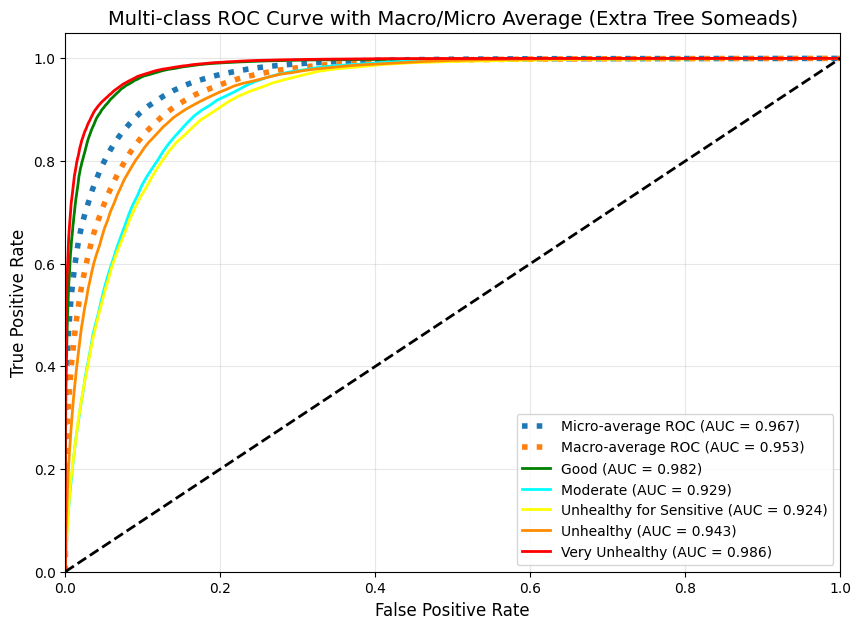

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# ============================================
# Multi-class ROC Curve (Test Set)
# ============================================

n_classes = y_test_bin.shape[1]

# คำนวณ ROC curve และ AUC สำหรับแต่ละ class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# คำนวณ micro-average ROC curve และ AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# คำนวณ macro-average ROC curve และ AUC
# รวม FPR ทั้งหมดของทุก class แล้วทำ interpolation
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ============================================
# Plot ROC Curves
# ============================================

plt.figure(figsize=(10, 7))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         linestyle=':', linewidth=4)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         linestyle=':', linewidth=4)

# Plot ROC ของแต่ละ class
colors = cycle(['green', 'aqua', 'yellow', 'darkorange', 'red'])
class_names = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve with Macro/Micro Average (Extra Tree Someads)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [3]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Binarize y_test
classes = [0, 1, 2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# คำนวณ fpr, tpr สำหรับแต่ละคลาส
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# รวม fpr ทั้งหมด
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate tpr
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_roc_auc = auc(all_fpr, mean_tpr)

# 🔽 Save fpr & tpr for later use
roc_df = pd.DataFrame({'fpr': all_fpr, 'tpr': mean_tpr})
roc_df.to_csv("roc_data_ETSomeads.csv", index=False)

# ✅ Print AUC and preview
print("Macro AUC =", round(macro_roc_auc, 4))
print(roc_df.head())


Macro AUC = 0.9528
        fpr       tpr
0  0.000000  0.000980
1  0.000013  0.028793
2  0.000014  0.029531
3  0.000016  0.034580
4  0.000020  0.043622
